# 03 · 迴歸：預測連續數值

分類是猜「哪一類」，**迴歸（regression）** 是預測「一個數字」——房價、氣溫、銷售額。這一課我們做線性與多項式迴歸，並學會用 **MSE / R²** 評估，用**殘差圖**診斷。

## 學習目標

- 用 `LinearRegression` 擬合資料，讀懂 `coef_`（斜率）與 `intercept_`（截距）
- 用 **MSE** 與 **R²** 評估迴歸模型
- 用 `PolynomialFeatures` 擬合非線性關係
- 用**殘差圖**判斷模型好不好

## 1. 造一份有雜訊的資料

為了看清楚原理，我們自己造一份「真實關係是直線、但帶雜訊」的資料。

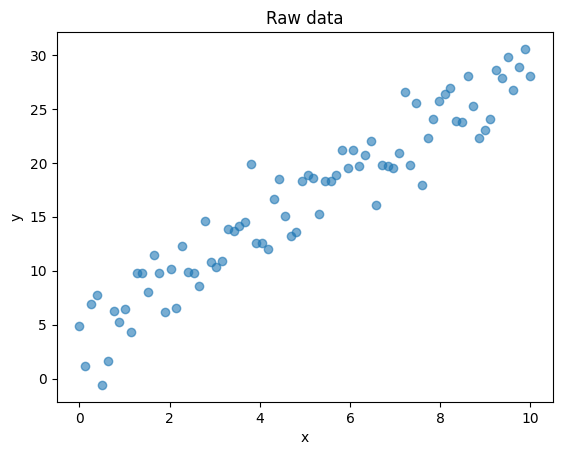

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
X = np.linspace(0, 10, 80).reshape(-1, 1)   # 特徵要是二維 (n, 1)
y = 2.5 * X.ravel() + 4 + rng.normal(0, 3, 80)  # 真實關係：y = 2.5x + 4 + 雜訊

plt.scatter(X, y, alpha=0.6)
plt.xlabel("x"); plt.ylabel("y"); plt.title("Raw data")
plt.show()

## 2. 線性迴歸

`fit` / `predict` 的節奏跟分類一模一樣。訓練完，模型學到的直線參數就放在 `coef_` 和 `intercept_` 裡。

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

lin = LinearRegression().fit(X_train, y_train)
print(f"學到的斜率 coef_:    {lin.coef_[0]:.2f}  (真實 2.5)")
print(f"學到的截距 intercept_: {lin.intercept_:.2f}  (真實 4.0)")

學到的斜率 coef_:    2.60  (真實 2.5)
學到的截距 intercept_: 3.36  (真實 4.0)


## 3. 評估：MSE 與 R²

- **MSE（均方誤差）**：預測值與真實值差距平方的平均，**越小越好**（有單位、隨資料尺度變）。
- **R²（決定係數）**：模型解釋了多少比例的變異，**越接近 1 越好**；0 代表跟「直接猜平均」一樣爛。

MSE: 7.72
R² : 0.826


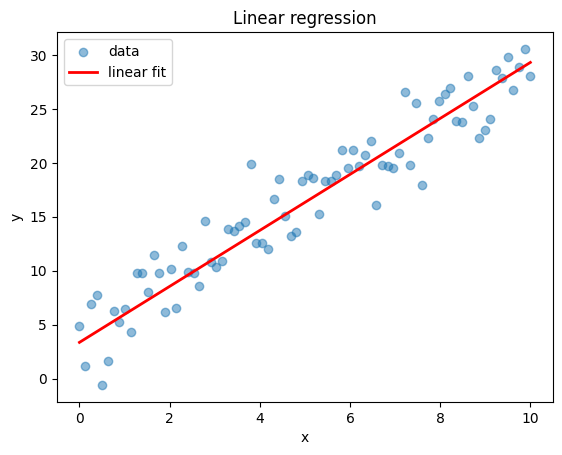

In [3]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = lin.predict(X_test)
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"R² : {r2_score(y_test, y_pred):.3f}")

# 把擬合的直線畫上去
plt.scatter(X, y, alpha=0.5, label="data")
plt.plot(X, lin.predict(X), color="red", lw=2, label="linear fit")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.title("Linear regression")
plt.show()

## 4. 非線性？用多項式特徵

如果真實關係是彎的，直線就不夠用了。技巧是：把特徵 `x` 擴充成 `x, x², x³…`，再丟給**同一個**線性迴歸——它就能擬合曲線。`PolynomialFeatures` + `LinearRegression` 用 `Pipeline` 串起來（下一課詳談 Pipeline）。

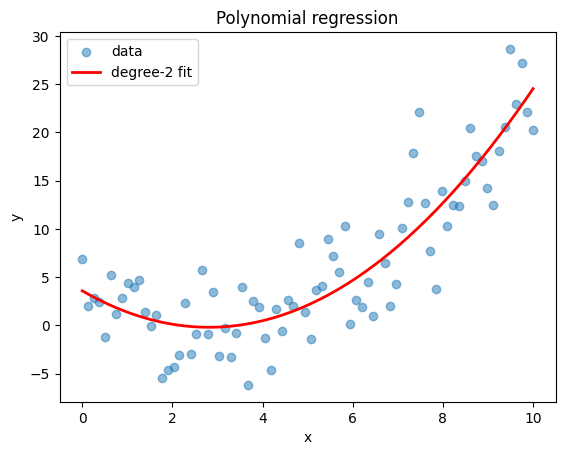

多項式擬合 R²: 0.785


In [4]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# 造一份彎的資料
y_curve = 0.5 * X.ravel()**2 - 3 * X.ravel() + 5 + rng.normal(0, 4, 80)

poly = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
poly.fit(X, y_curve)

xs = np.linspace(0, 10, 200).reshape(-1, 1)
plt.scatter(X, y_curve, alpha=0.5, label="data")
plt.plot(xs, poly.predict(xs), color="red", lw=2, label="degree-2 fit")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.title("Polynomial regression")
plt.show()
print(f"多項式擬合 R²: {poly.score(X, y_curve):.3f}")

## 5. 殘差圖：模型的健康檢查

**殘差 = 真實值 − 預測值**。把殘差對預測值畫散布圖：

- **健康**：殘差隨機散在 0 附近、沒有形狀 → 模型抓住了規律。
- **有問題**：殘差出現曲線、喇叭狀等模式 → 模型漏掉了某些結構（例如該用非線性卻用了直線）。

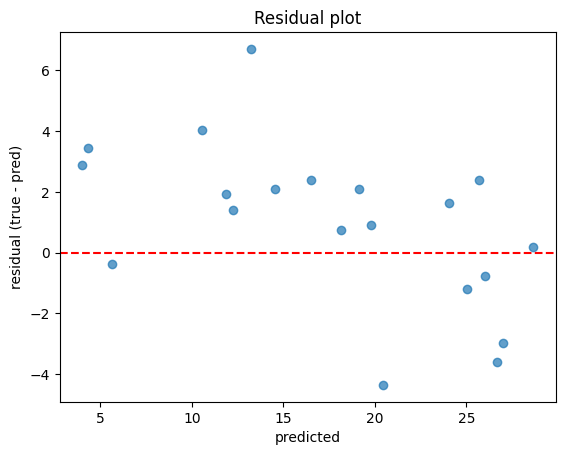

In [5]:
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(0, color="red", ls="--")
plt.xlabel("predicted"); plt.ylabel("residual (true - pred)")
plt.title("Residual plot")
plt.show()

## 小結

- 迴歸預測連續數值，流程與分類相同（`fit`/`predict`）。
- 線性迴歸的參數在 `coef_` / `intercept_`。
- 評估用 **MSE**（越小越好）和 **R²**（越接近 1 越好）。
- 非線性關係 → `PolynomialFeatures` 擴充特徵。
- **殘差圖**沒有形狀，才代表模型擬合得好。

## 練習

1. 把多項式 `degree` 從 2 一路加到 10，觀察 R² 與曲線——degree 太高會發生什麼事？（提示：過擬合）
2. 改用 sklearn 內建真實資料 `from sklearn.datasets import load_diabetes`，跑線性迴歸看 R²。

下一課，我們把 `StandardScaler`、`Pipeline` 講清楚——這是讓模型發揮實力、又不會作弊的關鍵。